# Yuki — Anime Character Storyboard
**Engine:** `pycairo` — real Bézier curves, gradients, path operations.  
No generative AI. No external assets. Fully deterministic.

In [2]:
pip install pycairo

   ---------------------------------------- 0.0/845.4 kB ? eta -:--:--
   --------------------------------------- 845.4/845.4 kB 18.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Cell 1 — Imports
import cairo
import math
import numpy as np
import io
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(42)          # deterministic everywhere

# ── Helpers to display a cairo ImageSurface inline ─────────────────────────
def surface_to_pil(surface):
    """Convert a pycairo ARGB32 surface → PIL Image (RGBA)."""
    w, h = surface.get_width(), surface.get_height()
    buf = surface.get_data()
    arr = np.frombuffer(buf, dtype=np.uint8).reshape(h, w, 4).copy()
    # Cairo stores BGRA on little-endian; convert → RGBA
    arr[:, :, 0], arr[:, :, 2] = arr[:, :, 2].copy(), arr[:, :, 0].copy()
    return Image.fromarray(arr, 'RGBA')

def show_surface(surface, title='', figsize=(6, 5)):
    """Render a cairo surface in the notebook immediately."""
    img = surface_to_pil(surface)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img)
    ax.axis('off')
    if title:
        ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
    plt.tight_layout()
    plt.show()

print('Imports OK — pycairo', cairo.version)


Imports OK — pycairo 1.29.0


In [4]:
# Cell 2 — Low-level pycairo drawing primitives

def set_rgba(ctx, hex_color, alpha=1.0):
    """Set source colour from #RRGGBB hex string + alpha."""
    h = hex_color.lstrip('#')
    r, g, b = (int(h[i:i+2], 16) / 255.0 for i in (0, 2, 4))
    ctx.set_source_rgba(r, g, b, alpha)

def fill_stroke(ctx, fill_hex, stroke_hex='#1A1A2E', lw=1.8, fill_alpha=1.0, stroke_alpha=1.0):
    """Fill then stroke the current path."""
    ctx.save()
    set_rgba(ctx, fill_hex, fill_alpha)
    ctx.fill_preserve()
    ctx.set_line_width(lw)
    ctx.set_line_join(cairo.LINE_JOIN_ROUND)
    ctx.set_line_cap(cairo.LINE_CAP_ROUND)
    set_rgba(ctx, stroke_hex, stroke_alpha)
    ctx.stroke()
    ctx.restore()

def fill_only(ctx, hex_color, alpha=1.0):
    ctx.save()
    set_rgba(ctx, hex_color, alpha)
    ctx.fill()
    ctx.restore()

def stroke_only(ctx, hex_color, lw=1.5, alpha=1.0):
    ctx.save()
    ctx.set_line_width(lw)
    ctx.set_line_cap(cairo.LINE_CAP_ROUND)
    ctx.set_line_join(cairo.LINE_JOIN_ROUND)
    set_rgba(ctx, hex_color, alpha)
    ctx.stroke()
    ctx.restore()

def apply_radial_shade(ctx, cx, cy, r0, r1, color_hex, alpha_inner=0.0, alpha_outer=0.25):
    """Overlay a radial gradient shading blob for depth."""
    h = color_hex.lstrip('#')
    r, g, b = (int(h[i:i+2], 16) / 255.0 for i in (0, 2, 4))
    grad = cairo.RadialGradient(cx, cy, r0, cx, cy, r1)
    grad.add_color_stop_rgba(0, r, g, b, alpha_inner)
    grad.add_color_stop_rgba(1, 0,   0,   0,   alpha_outer)
    ctx.save()
    ctx.set_source(grad)
    ctx.fill()
    ctx.restore()

print('Primitives defined')


Primitives defined


In [5]:
# Cell 3 — Colour palette (single source of truth)

C = dict(
    skin         = '#F5C8A8',
    skin_shadow  = '#D9A07A',
    skin_dark    = '#C8865A',
    hair         = '#5C2E0E',
    hair_mid     = '#7A3D18',
    hair_shine   = '#A0612A',
    eye_white    = '#EEF4FF',
    iris         = '#3B2A6E',
    pupil        = '#0D0820',
    eye_shine    = '#FFFFFF',
    eyelash      = '#1A0A05',
    brow         = '#3A1A08',
    lip          = '#D47A7A',
    nose         = '#D9A07A',
    tshirt       = '#A2D4EE',
    tshirt_s     = '#7BBAD6',
    coat         = '#F5CA0F',
    coat_s       = '#D4A800',
    coat_lining  = '#FFF0A0',
    shorts       = '#2E4E72',
    shorts_s     = '#1E3655',
    shorts_hi    = '#3E6492',
    leg          = '#F5C8A8',
    leg_shadow   = '#D9A07A',
    sock         = '#C8C8C8',
    sock_s       = '#A0A0A0',
    boot         = '#3A6EB5',
    boot_s       = '#2A55A0',
    boot_shine   = '#6AAAE8',
    outline      = '#1A1020',
    sky_top      = '#5AAAD8',
    sky_bot      = '#C8E8F8',
    ground       = '#6ABF5E',
    ground_d     = '#4A9040',
    soil         = '#8B6520',
    grass_a      = '#52A845',
    grass_b      = '#3D8A30',
    cloud        = '#FFFFFF',
    flower_pink  = '#F06090',
    flower_yel   = '#F5D020',
    flower_lav   = '#C090E0',
    petal_center = '#F5D020',
    stem         = '#4A8A30',
)
print('Palette ready —', len(C), 'colours')


Palette ready — 43 colours


In [6]:
# Cell 4 — Procedural background (sky gradient, ground, grass, clouds, flowers)

def draw_background(ctx, W, H, ground_y, rng=None):
    if rng is None:
        rng = np.random.default_rng(77)

    # ── Sky gradient ───────────────────────────────────────────────────────
    grad = cairo.LinearGradient(0, 0, 0, ground_y)
    def hx(c): h=c.lstrip('#'); return tuple(int(h[i:i+2],16)/255 for i in(0,2,4))
    r1,g1,b1 = hx(C['sky_top'])
    r2,g2,b2 = hx(C['sky_bot'])
    grad.add_color_stop_rgb(0, r1, g1, b1)
    grad.add_color_stop_rgb(1, r2, g2, b2)
    ctx.rectangle(0, 0, W, ground_y)
    ctx.set_source(grad)
    ctx.fill()

    # ── Clouds ────────────────────────────────────────────────────────────
    def cloud_blob(cx, cy, rx, ry):
        ctx.save()
        ctx.translate(cx, cy)
        ctx.scale(rx, ry)
        ctx.arc(0, 0, 1, 0, 2*math.pi)
        ctx.restore()

    cloud_specs = [
        (W*0.15, H*0.14, 55, 30),
        (W*0.38, H*0.09, 70, 35),
        (W*0.65, H*0.15, 60, 28),
        (W*0.82, H*0.10, 45, 22),
    ]
    for bx, by, rx, ry in cloud_specs:
        for dx, dy, sr, ss in [
            ( 0,    0,   1.0, 1.0),
            ( rx*0.55, -ry*0.25, 0.75, 0.80),
            (-rx*0.50, -ry*0.20, 0.70, 0.75),
            ( rx*0.25,  ry*0.20, 0.60, 0.65),
        ]:
            cloud_blob(bx+dx, by+dy, rx*sr, ry*ss)
            ctx.set_source_rgba(1, 1, 1, 0.90)
            ctx.fill()

    # ── Soil strip ────────────────────────────────────────────────────────
    h2=C['soil'].lstrip('#'); rs,gs,bs=(int(h2[i:i+2],16)/255 for i in(0,2,4))
    ctx.rectangle(0, ground_y, W, H - ground_y)
    ctx.set_source_rgb(rs, gs, bs)
    ctx.fill()

    # ── Grass base strip ──────────────────────────────────────────────────
    h3=C['ground'].lstrip('#'); rg,gg,bg=(int(h3[i:i+2],16)/255 for i in(0,2,4))
    ctx.rectangle(0, ground_y - 12, W, 18)
    ctx.set_source_rgb(rg, gg, bg)
    ctx.fill()

    # ── Grass tufts (bezier blades) ───────────────────────────────────────
    xs = rng.uniform(0, W, 55)
    for x in xs:
        gy = ground_y + rng.uniform(-4, 4)
        h  = rng.uniform(14, 36)
        w  = rng.uniform(3, 8)
        lean = rng.uniform(-8, 8)
        col = C['grass_a'] if rng.random() > 0.45 else C['grass_b']
        ctx.move_to(x - w/2, gy)
        ctx.curve_to(x - w/2, gy - h*0.4,
                     x + lean + w*0.3, gy - h*0.7,
                     x + lean, gy - h)
        ctx.curve_to(x + lean - w*0.3, gy - h*0.7,
                     x + w/2, gy - h*0.4,
                     x + w/2, gy)
        ctx.close_path()
        fill_only(ctx, col)

def draw_flower_cairo(ctx, fx, fy, size=22, color=None, rng=None):
    """5-petal daisy with bezier petals drawn in pycairo."""
    if rng is None: rng = np.random.default_rng(5)
    if color is None: color = C['flower_pink']

    # Stem
    ctx.move_to(fx, fy)
    ctx.line_to(fx + rng.uniform(-4,4), fy + size*1.8)
    ctx.set_line_width(1.8)
    set_rgba(ctx, C['stem'])
    ctx.stroke()

    # Petals
    for i in range(5):
        angle = i * 2 * math.pi / 5 - math.pi/2
        px = fx + math.cos(angle) * size * 1.15
        py = fy + math.sin(angle) * size * 1.15
        ctx.save()
        ctx.translate(fx, fy)
        ctx.rotate(angle)
        ctx.scale(size * 0.48, size * 0.90)
        ctx.arc(0, 1, 1, 0, 2*math.pi)
        ctx.restore()
        fill_only(ctx, color, 0.92)
        ctx.save()
        ctx.translate(fx, fy)
        ctx.rotate(angle)
        ctx.scale(size * 0.48, size * 0.90)
        ctx.arc(0, 1, 1, 0, 2*math.pi)
        ctx.restore()
        ctx.set_line_width(0.8)
        set_rgba(ctx, C['outline'], 0.4)
        ctx.stroke()

    # Centre disc
    ctx.arc(fx, fy, size*0.40, 0, 2*math.pi)
    fill_stroke(ctx, C['petal_center'], C['outline'], lw=1.0)

print('Background helpers defined')


Background helpers defined


In [7]:
# Cell 5 — AnimeCharacter class
# All body parts drawn with pycairo Bézier curves + gradients.
# Pose is fully parametric via a dict.

class AnimeCharacter:
    """
    8-year-old anime girl:
      • Short brown bob hair
      • Yellow raincoat (open), light-blue t-shirt
      • Dark denim shorts (mid-thigh)
      • Bare legs, gray ankle socks, blue mid-calf rain boots

    draw(ctx, ox, oy, scale, pose) renders her into any cairo Context.
    ox, oy = bottom-centre anchor (feet position).
    scale  = pixels per 'unit' (base unit = 1).
    pose   = dict overriding any default pose keys.
    """

    # ── Skeleton proportions (in abstract units, scale applied at draw time) ──
    # Using child proportions: ~5.5 heads tall total
    HEAD_R        = 1.00   # reference: head radius = 1 unit
    NECK_H        = 0.40
    TORSO_H       = 2.20
    TORSO_W       = 1.55
    SHOULDER_W    = 1.80
    HIP_W         = 1.40
    UPPER_ARM_L   = 1.10
    UPPER_ARM_W   = 0.40
    LOWER_ARM_L   = 1.00
    LOWER_ARM_W   = 0.32
    HAND_R        = 0.22
    UPPER_LEG_L   = 1.45
    UPPER_LEG_W   = 0.52
    LOWER_LEG_L   = 1.20
    LOWER_LEG_W   = 0.40
    ANKLE_W       = 0.32
    SOCK_H        = 0.28
    BOOT_H        = 0.70
    BOOT_W        = 0.46
    FOOT_L        = 0.55

    def __init__(self, name='Yuki'):
        self.name = name

    # ── Default neutral pose ──────────────────────────────────────────────
    def _default_pose(self):
        return dict(
            facing        = 'front',   # 'front'|'back'|'side_r'|'side_l'
            # Arm angles (degrees from vertical; +ve = forward/outward)
            l_upper_arm   = -8.0,
            l_lower_arm   =  5.0,
            r_upper_arm   =  8.0,
            r_lower_arm   = -5.0,
            # Leg angles (degrees from vertical; +ve = forward)
            l_upper_leg   =  4.0,
            l_lower_leg   = -3.0,
            r_upper_leg   = -4.0,
            r_lower_leg   =  3.0,
            # Global body lean
            body_tilt     =  0.0,
            head_tilt     =  0.0,    # + = tilt right
            head_turn     =  0.0,    # + = turn right (front/back only)
            # Crouch compresses the figure (0=standing, 1=full squat)
            crouch        =  0.0,
            # Feet / boot direction (for side view)
            foot_angle    =  0.0,
        )

    # ─────────────────────────────────────────────────────────────────────
    def draw(self, ctx, ox, oy, scale=55, pose=None):
        """
        Render Yuki into *ctx* with feet-bottom at (ox, oy).
        scale: pixels per HEAD_R unit (55 → head radius ~55 px).
        """
        p = self._default_pose()
        if pose:
            p.update(pose)
        s       = scale
        cr      = p['crouch']
        facing  = p['facing']
        side    = facing in ('side_r', 'side_l')
        back    = facing == 'back'
        flip    = (facing == 'side_l')

        # ── Compute skeleton Y positions bottom-up ────────────────────────
        boot_top_y   = oy  - self.BOOT_H   * s
        sock_top_y   = boot_top_y - self.SOCK_H * s * 0.7
        knee_y       = oy  - (self.BOOT_H + self.LOWER_LEG_L * (1 - 0.35*cr)) * s
        hip_y        = knee_y - self.UPPER_LEG_L * (1 - 0.35*cr) * s
        waist_y      = hip_y  - self.TORSO_H * 0.15 * s
        chest_y      = hip_y  - self.TORSO_H * (1 - 0.15*cr) * s
        shoulder_y   = chest_y + self.NECK_H * 0.25 * s
        neck_top_y   = chest_y - self.NECK_H * s * 0.5
        head_cy      = neck_top_y - self.HEAD_R * s * 0.85

        # Horizontal offsets
        hw = self.HIP_W * s * 0.5 * (0.35 if side else 1.0)
        sw = self.SHOULDER_W * s * 0.5 * (0.35 if side else 1.0)

        # ── Draw back-layer limbs first ───────────────────────────────────
        ctx.save()
        if flip:
            ctx.translate(ox, 0)
            ctx.scale(-1, 1)
            ctx.translate(-ox, 0)

        if not side:
            self._arm(ctx, ox - sw, shoulder_y, p['l_upper_arm'], p['l_lower_arm'],
                      s, back, 'back_layer', side=False)
            self._leg(ctx, ox - hw, oy, knee_y, hip_y,
                      p['l_upper_leg'], p['l_lower_leg'],
                      s, back, 'back_layer', side=False)
        else:
            self._leg(ctx, ox, oy, knee_y, hip_y,
                      p['r_upper_leg'], p['r_lower_leg'],
                      s, back, 'back_layer', side=True)

        # ── Torso ─────────────────────────────────────────────────────────
        self._torso(ctx, ox, hip_y, chest_y, waist_y, shoulder_y, s, p, side, back)

        # ── Front-layer limbs ─────────────────────────────────────────────
        if not side:
            self._leg(ctx, ox + hw, oy, knee_y, hip_y,
                      p['r_upper_leg'], p['r_lower_leg'],
                      s, back, 'front_layer', side=False)
            self._arm(ctx, ox + sw, shoulder_y, p['r_upper_arm'], p['r_lower_arm'],
                      s, back, 'front_layer', side=False)
        else:
            self._arm(ctx, ox, shoulder_y, p['r_upper_arm'], p['r_lower_arm'],
                      s, back, 'front_layer', side=True)
            self._leg(ctx, ox, oy, knee_y, hip_y,
                      p['l_upper_leg'], p['l_lower_leg'],
                      s, back, 'front_layer', side=True)

        # ── Head ──────────────────────────────────────────────────────────
        self._head(ctx, ox, head_cy, neck_top_y, s, p, back, side)

        ctx.restore()

    # ─────────────────────────────────────────────────────────────────────
    # HEAD
    # ─────────────────────────────────────────────────────────────────────
    def _head(self, ctx, cx, cy, neck_y, s, p, back, side):
        HR  = self.HEAD_R * s
        tilt = p['head_tilt']

        ctx.save()
        ctx.translate(cx, cy)
        ctx.rotate(math.radians(tilt))

        # ── Neck ──────────────────────────────────────────────────────────
        nw = HR * 0.30
        ctx.move_to(-nw, 0)
        ctx.line_to( nw, 0)
        ctx.line_to( nw * 0.8, HR * 0.7)
        ctx.line_to(-nw * 0.8, HR * 0.7)
        ctx.close_path()
        fill_stroke(ctx, C['skin'], C['outline'], lw=1.2)

        # ── Head shape (slightly pointed chin — anime style) ───────────────
        hw = HR * (0.55 if side else 1.00)
        ctx.move_to(0, -HR * 1.02)
        ctx.curve_to( hw,    -HR * 0.90,   hw*1.05, -HR*0.30,  hw*0.95,  HR*0.20)
        ctx.curve_to( hw*0.85, HR * 0.65,  hw*0.40,  HR*0.95,  0,        HR * 1.05)
        ctx.curve_to(-hw*0.40, HR * 0.95, -hw*0.85,  HR*0.65, -hw*0.95,  HR*0.20)
        ctx.curve_to(-hw*1.05,-HR * 0.30, -hw,      -HR*0.90,  0,       -HR * 1.02)
        ctx.close_path()
        fill_stroke(ctx, C['skin'], C['outline'], lw=1.8)

        # ── Shading on face (soft radial) ─────────────────────────────────
        ctx.move_to(0, -HR * 1.02)
        ctx.curve_to( hw, -HR*0.90, hw*1.05, -HR*0.30, hw*0.95, HR*0.20)
        ctx.curve_to( hw*0.85, HR*0.65, hw*0.40, HR*0.95, 0, HR*1.05)
        ctx.curve_to(-hw*0.40, HR*0.95, -hw*0.85, HR*0.65, -hw*0.95, HR*0.20)
        ctx.curve_to(-hw*1.05, -HR*0.30, -hw, -HR*0.90, 0, -HR*1.02)
        ctx.close_path()
        apply_radial_shade(ctx, hw*0.3, -HR*0.1, HR*0.1, HR*1.4, C['skin_dark'],
                           alpha_inner=0.0, alpha_outer=0.18)

        # ── Hair ──────────────────────────────────────────────────────────
        self._hair(ctx, HR, side, back, p)

        # ── Face features ─────────────────────────────────────────────────
        if not back:
            self._face(ctx, HR, side, p)

        ctx.restore()

    def _hair(self, ctx, HR, side, back, p):
        hw = HR * (0.55 if side else 1.00)

        # ── Main hair cap ─────────────────────────────────────────────────
        ctx.move_to(-hw * 0.10, -HR * 0.98)
        ctx.curve_to(-hw * 0.60, -HR * 1.25,
                     -hw * 1.20, -HR * 0.85,
                     -hw * 1.05, -HR * 0.15)
        ctx.curve_to(-hw * 1.00,  HR * 0.25,
                     -hw * 0.88,  HR * 0.62,
                     -hw * 0.65,  HR * 0.80)   # left side end
        ctx.line_to(-hw * 0.35,  HR * 0.95)    # bottom of bob left
        ctx.curve_to( hw * 0.00,  HR * 1.12,
                      hw * 0.35,  HR * 1.05,
                      hw * 0.65,  HR * 0.80)   # right side
        ctx.curve_to( hw * 0.88,  HR * 0.62,
                      hw * 1.00,  HR * 0.25,
                      hw * 1.05, -HR * 0.15)
        ctx.curve_to( hw * 1.20, -HR * 0.85,
                      hw * 0.60, -HR * 1.25,
                      hw * 0.10, -HR * 0.98)
        ctx.close_path()
        fill_stroke(ctx, C['hair'], C['outline'], lw=2.0)

        # ── Fringe (front-facing only) ─────────────────────────────────────
        if not side and not back:
            # Fringe sweeps across forehead
            ctx.move_to(-hw * 0.95, -HR * 0.12)
            ctx.curve_to(-hw * 0.80, -HR * 0.65,
                         -hw * 0.45, -HR * 0.82,
                         -hw * 0.20, -HR * 0.60)
            ctx.curve_to(-hw * 0.05, -HR * 0.45,
                          hw * 0.05, -HR * 0.45,
                          hw * 0.20, -HR * 0.60)
            ctx.curve_to( hw * 0.45, -HR * 0.82,
                          hw * 0.80, -HR * 0.65,
                          hw * 0.95, -HR * 0.12)
            ctx.curve_to( hw * 0.80, -HR * 0.25,
                          hw * 0.30, -HR * 0.35,
                          0,         -HR * 0.30)
            ctx.curve_to(-hw * 0.30, -HR * 0.35,
                         -hw * 0.80, -HR * 0.25,
                         -hw * 0.95, -HR * 0.12)
            ctx.close_path()
            fill_stroke(ctx, C['hair'], C['hair'], lw=0.5)

            # Hair highlight streak
            ctx.move_to(-hw*0.15, -HR*0.92)
            ctx.curve_to( hw*0.10, -HR*0.85,
                          hw*0.30, -HR*0.70,
                          hw*0.20, -HR*0.50)
            ctx.set_line_width(2.5)
            set_rgba(ctx, C['hair_shine'], 0.65)
            ctx.stroke()

        elif side:
            # Side fringe
            ctx.move_to(hw * 0.70, -HR * 0.10)
            ctx.curve_to(hw * 0.60, -HR * 0.55,
                         hw * 0.25, -HR * 0.75,
                         hw * 0.05, -HR * 0.55)
            ctx.curve_to(-hw*0.05, -HR*0.40,
                         -hw*0.05, -HR*0.20,
                          hw*0.05, -HR*0.10)
            ctx.close_path()
            fill_only(ctx, C['hair'])
            # Highlight
            ctx.move_to(hw*0.30, -HR*0.80)
            ctx.curve_to(hw*0.15, -HR*0.60, hw*0.10, -HR*0.40, hw*0.20, -HR*0.20)
            ctx.set_line_width(2.0)
            set_rgba(ctx, C['hair_shine'], 0.55)
            ctx.stroke()

    def _face(self, ctx, HR, side, p):
        """Eyes, eyebrows, nose, mouth — all drawn with pycairo paths."""
        # Positions depend on facing
        if not side:
            ex_l, ex_r = -HR * 0.38, HR * 0.38
            ey = HR * 0.05
            ew, eh = HR * 0.26, HR * 0.30
        else:
            ex_l, ex_r = HR * 0.32, HR * 0.32
            ey = HR * 0.05
            ew, eh = HR * 0.20, HR * 0.26

        eyes = [ex_r] if side else [ex_l, ex_r]
        for ex in eyes:
            # White sclera
            ctx.save()
            ctx.translate(ex, ey)
            ctx.scale(ew, eh)
            ctx.arc(0, 0, 1, 0, 2*math.pi)
            ctx.restore()
            fill_stroke(ctx, C['eye_white'], C['eyelash'], lw=1.2)

            # Iris (large anime iris)
            ctx.save()
            ctx.translate(ex, ey + eh*0.05)
            ctx.scale(ew * 0.72, eh * 0.82)
            ctx.arc(0, 0, 1, 0, 2*math.pi)
            ctx.restore()
            fill_only(ctx, C['iris'])

            # Iris gradient highlight
            rg = cairo.RadialGradient(ex + ew*0.18, ey - eh*0.22, 0,
                                      ex, ey + eh*0.05, eh*0.82)
            rg.add_color_stop_rgba(0, 0.7, 0.6, 1.0, 0.6)
            rg.add_color_stop_rgba(1, 0,   0,   0,   0.0)
            ctx.save()
            ctx.translate(ex, ey + eh*0.05)
            ctx.scale(ew * 0.72, eh * 0.82)
            ctx.arc(0, 0, 1, 0, 2*math.pi)
            ctx.restore()
            ctx.set_source(rg)
            ctx.fill()

            # Pupil
            ctx.arc(ex + ew*0.05, ey + eh*0.08, ew*0.30, 0, 2*math.pi)
            fill_only(ctx, C['pupil'])

            # Catchlight (two white dots)
            ctx.arc(ex + ew*0.32, ey - eh*0.28, ew*0.14, 0, 2*math.pi)
            fill_only(ctx, C['eye_shine'])
            ctx.arc(ex - ew*0.15, ey + eh*0.05, ew*0.07, 0, 2*math.pi)
            fill_only(ctx, C['eye_shine'], 0.6)

            # Upper eyelash line
            ctx.save()
            ctx.translate(ex, ey)
            ctx.scale(ew * 1.05, eh * 0.48)
            ctx.arc(0, -0.52, 1, math.pi*1.05, math.pi*1.95)
            ctx.restore()
            ctx.set_line_width(2.0)
            set_rgba(ctx, C['eyelash'])
            ctx.stroke()

        # ── Eyebrows ───────────────────────────────────────────────────────
        brows = [ex_r] if side else [ex_l, ex_r]
        for bx in brows:
            sign = 1 if bx > 0 else -1
            by = ey - eh * 1.30
            ctx.move_to(bx - ew*0.80*sign, by + HR*0.04)
            ctx.curve_to(bx - ew*0.30*sign, by - HR*0.04,
                         bx + ew*0.30*sign, by - HR*0.06,
                         bx + ew*0.80*sign, by + HR*0.02)
            ctx.set_line_width(2.8)
            ctx.set_line_cap(cairo.LINE_CAP_ROUND)
            set_rgba(ctx, C['brow'])
            ctx.stroke()

        # ── Nose (small, anime-minimal) ────────────────────────────────────
        nx = HR * 0.12 if side else 0
        ny = HR * 0.45
        ctx.arc(nx, ny, HR * 0.055, 0, 2*math.pi)
        fill_only(ctx, C['skin_shadow'], 0.55)

        # ── Mouth (small, slightly open) ──────────────────────────────────
        mx = HR * 0.08 if side else 0
        my = HR * 0.70
        ctx.move_to(mx - HR*0.16, my)
        ctx.curve_to(mx - HR*0.05, my + HR*0.10,
                     mx + HR*0.05, my + HR*0.10,
                     mx + HR*0.16, my)
        ctx.set_line_width(1.6)
        set_rgba(ctx, C['lip'])
        ctx.stroke()

        # Blush circles
        if not side:
            for bx in [-HR*0.62, HR*0.62]:
                grad = cairo.RadialGradient(bx, HR*0.42, 0, bx, HR*0.42, HR*0.22)
                grad.add_color_stop_rgba(0, 1, 0.5, 0.5, 0.32)
                grad.add_color_stop_rgba(1, 1, 0.5, 0.5, 0.0)
                ctx.arc(bx, HR*0.42, HR*0.22, 0, 2*math.pi)
                ctx.set_source(grad)
                ctx.fill()

    # ─────────────────────────────────────────────────────────────────────
    # TORSO
    # ─────────────────────────────────────────────────────────────────────
    def _torso(self, ctx, cx, hip_y, chest_y, waist_y, shoulder_y, s, p, side, back):
        sw = self.SHOULDER_W * s * (0.42 if side else 1.0)
        hw = self.HIP_W      * s * (0.42 if side else 1.0)
        ww = hw * 0.92

        # ── T-shirt body ──────────────────────────────────────────────────
        ctx.move_to(cx - sw, shoulder_y)
        ctx.curve_to(cx - sw*1.08, waist_y, cx - ww, waist_y, cx - hw*0.90, hip_y)
        ctx.line_to( cx + hw*0.90, hip_y)
        ctx.curve_to(cx + ww, waist_y, cx + sw*1.08, waist_y, cx + sw, shoulder_y)
        ctx.close_path()
        fill_stroke(ctx, C['tshirt'], C['outline'], lw=2.0)

        # Shirt fold lines
        ctx.move_to(cx - sw*0.25, shoulder_y + (hip_y-shoulder_y)*0.3)
        ctx.curve_to(cx - sw*0.10, shoulder_y + (hip_y-shoulder_y)*0.6,
                     cx + sw*0.05, shoulder_y + (hip_y-shoulder_y)*0.65,
                     cx + sw*0.10, hip_y - s*0.05)
        ctx.set_line_width(1.0)
        set_rgba(ctx, C['tshirt_s'], 0.60)
        ctx.stroke()

        # ── Raincoat panels (open, overlapping sides) ──────────────────────
        if not side:
            # Left coat panel
            ctx.move_to(cx - sw*0.02, shoulder_y - s*0.08)
            ctx.curve_to(cx - sw*0.80, shoulder_y + s*0.05,
                         cx - sw*1.25, waist_y - s*0.10,
                         cx - sw*1.15, hip_y + s*0.05)
            ctx.curve_to(cx - sw*1.05, hip_y + s*0.20,
                         cx - sw*0.35, hip_y + s*0.15,
                         cx - sw*0.05, hip_y + s*0.08)
            ctx.close_path()
            fill_stroke(ctx, C['coat'], C['outline'], lw=1.8)
            # Lapel (darker lining colour)
            ctx.move_to(cx - sw*0.02, shoulder_y - s*0.08)
            ctx.curve_to(cx - sw*0.45, shoulder_y - s*0.02,
                         cx - sw*0.55, waist_y + s*0.25,
                         cx - sw*0.18, waist_y + s*0.30)
            ctx.line_to(cx - sw*0.05, hip_y + s*0.08)
            ctx.close_path()
            fill_stroke(ctx, C['coat_s'], C['outline'], lw=1.0)

            # Right coat panel
            ctx.move_to(cx + sw*0.02, shoulder_y - s*0.08)
            ctx.curve_to(cx + sw*0.80, shoulder_y + s*0.05,
                         cx + sw*1.25, waist_y - s*0.10,
                         cx + sw*1.15, hip_y + s*0.05)
            ctx.curve_to(cx + sw*1.05, hip_y + s*0.20,
                         cx + sw*0.35, hip_y + s*0.15,
                         cx + sw*0.05, hip_y + s*0.08)
            ctx.close_path()
            fill_stroke(ctx, C['coat'], C['outline'], lw=1.8)
            # Right lapel
            ctx.move_to(cx + sw*0.02, shoulder_y - s*0.08)
            ctx.curve_to(cx + sw*0.45, shoulder_y - s*0.02,
                         cx + sw*0.55, waist_y + s*0.25,
                         cx + sw*0.18, waist_y + s*0.30)
            ctx.line_to(cx + sw*0.05, hip_y + s*0.08)
            ctx.close_path()
            fill_stroke(ctx, C['coat_s'], C['outline'], lw=1.0)

        else:
            # Side: one visible coat panel
            ctx.move_to(cx - sw*0.05, shoulder_y - s*0.08)
            ctx.curve_to(cx - sw*0.50, shoulder_y + s*0.10,
                         cx - sw*0.80, waist_y,
                         cx - sw*0.75, hip_y + s*0.05)
            ctx.curve_to(cx - sw*0.65, hip_y + s*0.20,
                         cx + sw*0.15, hip_y + s*0.12,
                         cx + sw*0.08, hip_y + s*0.05)
            ctx.curve_to(cx + sw*0.60, waist_y + s*0.10,
                         cx + sw*0.55, shoulder_y + s*0.05,
                         cx + sw*0.08, shoulder_y - s*0.08)
            ctx.close_path()
            fill_stroke(ctx, C['coat'], C['outline'], lw=1.8)

        # ── Shorts ────────────────────────────────────────────────────────
        sh_h = self.UPPER_LEG_L * s * 0.52
        ctx.move_to(cx - hw*0.92, hip_y)
        ctx.curve_to(cx - hw*0.95, hip_y + sh_h*0.5,
                     cx - hw*0.80, hip_y + sh_h,
                     cx - hw*0.55, hip_y + sh_h)
        ctx.line_to( cx + hw*0.55, hip_y + sh_h)
        ctx.curve_to(cx + hw*0.80, hip_y + sh_h,
                     cx + hw*0.95, hip_y + sh_h*0.5,
                     cx + hw*0.92, hip_y)
        ctx.close_path()
        fill_stroke(ctx, C['shorts'], C['outline'], lw=2.0)

        # Shorts highlight seam
        ctx.move_to(cx - hw*0.50, hip_y + sh_h*0.25)
        ctx.curve_to(cx - hw*0.20, hip_y + sh_h*0.65,
                     cx + hw*0.05, hip_y + sh_h*0.70,
                     cx + hw*0.20, hip_y + sh_h*0.50)
        ctx.set_line_width(1.2)
        set_rgba(ctx, C['shorts_hi'], 0.55)
        ctx.stroke()

    # ─────────────────────────────────────────────────────────────────────
    # ARM
    # ─────────────────────────────────────────────────────────────────────
    def _arm(self, ctx, sx, sy, upper_ang, lower_ang, s, back, layer, side=False):
        ua = math.radians(upper_ang)
        la = math.radians(upper_ang + lower_ang)
        uaw = self.UPPER_ARM_W * s * (0.55 if side else 1.0)
        law = self.LOWER_ARM_W * s * (0.55 if side else 1.0)
        ual = self.UPPER_ARM_L * s
        lal = self.LOWER_ARM_L * s

        # Elbow pos
        ex = sx + math.sin(ua) * ual
        ey = sy + math.cos(ua) * ual
        # Wrist pos
        wx = ex + math.sin(la) * lal
        wy = ey + math.cos(la) * lal

        # Perpendicular offsets
        def perp(angle, w):
            return -math.cos(angle)*w, math.sin(angle)*w

        # ── Upper arm (coat sleeve) ────────────────────────────────────────
        pdx, pdy = perp(ua, uaw)
        ctx.move_to(sx + pdx, sy + pdy)
        ctx.curve_to(sx + pdx + math.sin(ua)*ual*0.4, sy + pdy + math.cos(ua)*ual*0.4,
                     ex + pdx, ey + pdy,
                     ex + pdx, ey + pdy)
        ctx.line_to(ex - pdx, ey - pdy)
        ctx.curve_to(ex - pdx, ey - pdy,
                     sx - pdx + math.sin(ua)*ual*0.4, sy - pdy + math.cos(ua)*ual*0.4,
                     sx - pdx, sy - pdy)
        ctx.close_path()
        col = C['coat'] if layer == 'front_layer' else C['coat_s']
        fill_stroke(ctx, col, C['outline'], lw=1.8)

        # ── Lower arm (skin forearm below sleeve) ─────────────────────────
        pdx2, pdy2 = perp(la, law)
        ctx.move_to(ex + pdx2, ey + pdy2)
        ctx.curve_to(ex + pdx2, ey + pdy2,
                     wx + pdx2, wy + pdy2,
                     wx + pdx2, wy + pdy2)
        ctx.line_to(wx - pdx2, wy - pdy2)
        ctx.curve_to(wx - pdx2, wy - pdy2,
                     ex - pdx2, ey - pdy2,
                     ex - pdx2, ey - pdy2)
        ctx.close_path()
        fill_stroke(ctx, C['skin'], C['outline'], lw=1.5)

        # ── Hand ──────────────────────────────────────────────────────────
        ctx.arc(wx, wy, self.HAND_R * s * (0.7 if side else 1.0), 0, 2*math.pi)
        fill_stroke(ctx, C['skin'], C['outline'], lw=1.2)

    # ─────────────────────────────────────────────────────────────────────
    # LEG
    # ─────────────────────────────────────────────────────────────────────
    def _leg(self, ctx, hx, hy, knee_y_default, hip_y_default,
             upper_ang, lower_ang, s, back, layer, side=False):
        ua = math.radians(upper_ang)
        la = math.radians(upper_ang + lower_ang)
        ulw = self.UPPER_LEG_W * s * (0.55 if side else 1.0)
        llw = self.LOWER_LEG_W * s * (0.55 if side else 1.0)
        ull = self.UPPER_LEG_L * s
        lll = self.LOWER_LEG_L * s

        # Hip origin (bottom of shorts)
        hip_bot_y = hip_y_default + self.UPPER_LEG_L * s * 0.52

        # Knee pos
        kx = hx + math.sin(ua) * ull
        ky = hip_bot_y + math.cos(ua) * ull

        # Ankle pos
        ax = kx + math.sin(la) * lll
        ay = ky + math.cos(la) * lll

        def perp(angle, w):
            return -math.cos(angle)*w, math.sin(angle)*w

        # ── Upper leg (bare skin) ─────────────────────────────────────────
        pdx, pdy = perp(ua, ulw)
        ctx.move_to(hx + pdx, hip_bot_y + pdy)
        ctx.curve_to(hx + pdx + math.sin(ua)*ull*0.5, hip_bot_y + pdy + math.cos(ua)*ull*0.5,
                     kx + pdx*0.95, ky + pdy*0.95,
                     kx, ky + ulw*0.05)
        ctx.curve_to(kx - pdx*0.95, ky - pdy*0.95,
                     hx - pdx + math.sin(ua)*ull*0.5, hip_bot_y - pdy + math.cos(ua)*ull*0.5,
                     hx - pdx, hip_bot_y - pdy)
        ctx.close_path()
        fill_stroke(ctx, C['leg'], C['outline'], lw=1.8)

        # Leg shading
        ctx.move_to(hx + pdx, hip_bot_y + pdy)
        ctx.curve_to(hx + pdx + math.sin(ua)*ull*0.5, hip_bot_y + pdy + math.cos(ua)*ull*0.5,
                     kx + pdx*0.95, ky + pdy*0.95,
                     kx, ky + ulw*0.05)
        ctx.curve_to(kx - pdx*0.95, ky - pdy*0.95,
                     hx - pdx + math.sin(ua)*ull*0.5, hip_bot_y - pdy + math.cos(ua)*ull*0.5,
                     hx - pdx, hip_bot_y - pdy)
        ctx.close_path()
        apply_radial_shade(ctx, hx + pdx*0.5, hip_bot_y + ull*0.3,
                           ulw*0.3, ulw*1.6, C['leg_shadow'],
                           alpha_inner=0.0, alpha_outer=0.20)

        # ── Lower leg ─────────────────────────────────────────────────────
        pdx2, pdy2 = perp(la, llw)
        ctx.move_to(kx + pdx2*0.9, ky + pdy2*0.9)
        ctx.curve_to(kx + pdx2 + math.sin(la)*lll*0.4, ky + pdy2 + math.cos(la)*lll*0.4,
                     ax + pdx2, ay + pdy2,
                     ax + pdx2*0.85, ay + pdy2*0.85)
        ctx.line_to(ax - pdx2*0.85, ay - pdy2*0.85)
        ctx.curve_to(ax - pdx2, ay - pdy2,
                     kx - pdx2 + math.sin(la)*lll*0.4, ky - pdy2 + math.cos(la)*lll*0.4,
                     kx - pdx2*0.9, ky - pdy2*0.9)
        ctx.close_path()
        fill_stroke(ctx, C['leg'], C['outline'], lw=1.8)

        # ── Sock ─────────────────────────────────────────────────────────
        SOCKH = self.SOCK_H * s
        pdx3, pdy3 = perp(la, llw * 0.95)
        ctx.move_to(ax + pdx3, ay + pdy3)
        sx2 = ax + math.sin(la) * SOCKH
        sy2 = ay + math.cos(la) * SOCKH
        ctx.curve_to(ax + pdx3, ay + pdy3,
                     sx2 + pdx3, sy2 + pdy3,
                     sx2 + pdx3 * 0.9, sy2 + pdy3 * 0.9)
        ctx.line_to(sx2 - pdx3*0.9, sy2 - pdy3*0.9)
        ctx.curve_to(sx2 - pdx3, sy2 - pdy3,
                     ax - pdx3, ay - pdy3,
                     ax - pdx3, ay - pdy3)
        ctx.close_path()
        fill_stroke(ctx, C['sock'], C['outline'], lw=1.5)

        # ── Boot ─────────────────────────────────────────────────────────
        BOOTH = self.BOOT_H * s
        bw    = self.BOOT_W * s * (0.60 if side else 1.0)
        # Boot shaft top
        boot_top_x = sx2 + math.sin(la) * (BOOTH - SOCKH)
        boot_top_y = sy2 + math.cos(la) * (BOOTH - SOCKH)
        pdx4, pdy4 = perp(la, bw)

        ctx.move_to(sx2 + pdx4, sy2 + pdy4)
        ctx.curve_to(sx2 + pdx4, sy2 + pdy4,
                     boot_top_x + pdx4, boot_top_y + pdy4,
                     boot_top_x + pdx4, boot_top_y + pdy4)
        # Foot shape at bottom
        foot_ang = la + math.radians(p['foot_angle'] if 'foot_angle' in locals() else 0)
        fl = self.FOOT_L * s * (0.6 if side else 1.0)
        ctx.curve_to(boot_top_x + pdx4*0.8 + math.sin(foot_ang)*fl*0.5,
                     boot_top_y + pdy4*0.8 + math.cos(foot_ang)*fl*0.5,
                     boot_top_x + math.sin(foot_ang)*fl,
                     boot_top_y + math.cos(foot_ang)*fl,
                     boot_top_x + math.sin(foot_ang)*fl,
                     boot_top_y + math.cos(foot_ang)*fl)
        ctx.line_to(boot_top_x - pdx4*0.6 + math.sin(foot_ang)*fl*0.3,
                    boot_top_y - pdy4*0.6 + math.cos(foot_ang)*fl*0.3)
        ctx.curve_to(sx2 - pdx4, sy2 - pdy4,
                     sx2 - pdx4, sy2 - pdy4,
                     sx2 - pdx4, sy2 - pdy4)
        ctx.close_path()
        fill_stroke(ctx, C['boot'], C['outline'], lw=2.0)

        # Boot shine
        ctx.move_to(sx2 + pdx4*0.55, sy2 + pdy4*0.55)
        ctx.curve_to(sx2 + pdx4*0.55, sy2 + pdy4*0.55,
                     boot_top_x + pdx4*0.50, boot_top_y + pdy4*0.50,
                     boot_top_x + pdx4*0.35, boot_top_y + pdy4*0.35)
        ctx.set_line_width(3.5)
        set_rgba(ctx, C['boot_shine'], 0.55)
        ctx.stroke()

        # Sole line
        ctx.move_to(boot_top_x - pdx4*0.65 + math.sin(foot_ang)*fl*0.05,
                    boot_top_y - pdy4*0.65 + math.cos(foot_ang)*fl*0.05)
        ctx.line_to(boot_top_x + math.sin(foot_ang)*fl,
                    boot_top_y + math.cos(foot_ang)*fl)
        ctx.set_line_width(2.5)
        set_rgba(ctx, C['boot_s'], 0.8)
        ctx.stroke()

print('AnimeCharacter class defined — Bézier + gradient rendering')


AnimeCharacter class defined — Bézier + gradient rendering


In [8]:
# Cell 6 — Instantiate the ONE persistent character object
yuki = AnimeCharacter(name='Yuki')
print(f'Character "{yuki.name}" ready — will be reused across all 4 scenes.')


Character "Yuki" ready — will be reused across all 4 scenes.


In [9]:
# Cell 7 — Scene builder & stored scene surfaces

W, H = 720, 540
GROUND_Y = 380       # y-pixel of ground horizon
STORED_SURFACES = [] # collect for storyboard

def make_surface():
    return cairo.ImageSurface(cairo.FORMAT_ARGB32, W, H)

def render_scene(title, draw_fn, show=True, figsize=(8, 6)):
    """Create surface → draw background → call draw_fn(ctx) → show."""
    surf = make_surface()
    ctx  = cairo.Context(surf)
    rng  = np.random.default_rng(99)   # same seed = same background every scene
    draw_background(ctx, W, H, GROUND_Y, rng=rng)
    draw_fn(ctx)
    STORED_SURFACES.append(surf)
    if show:
        show_surface(surf, title=title, figsize=figsize)
    return surf

print('Scene scaffolding ready')


Scene scaffolding ready


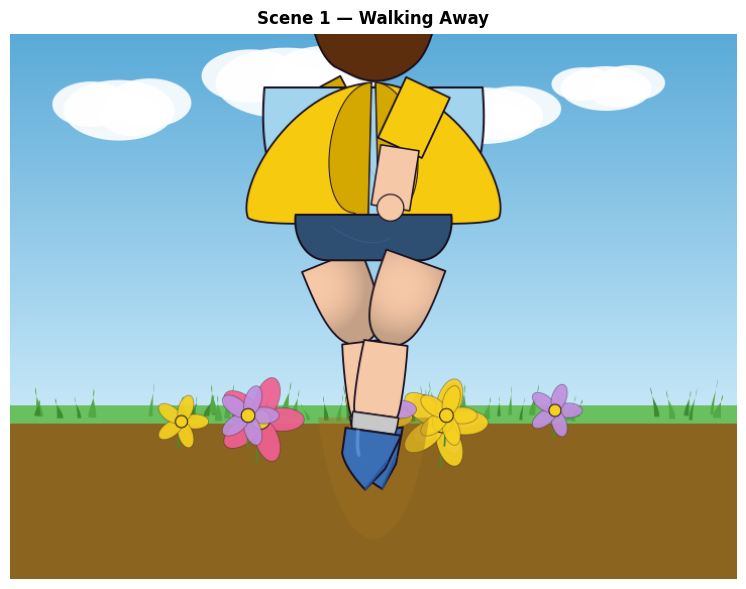

Scene 1 rendered


In [10]:
# Cell 8 — Scene 1: Walking Away (back-facing, mid-stride)

def scene1(ctx):
    rng = np.random.default_rng(7)
    # Scatter flowers behind her
    for _ in range(9):
        fx = rng.uniform(80, W-80)
        fy = GROUND_Y + rng.integers(-8, 6)
        col = rng.choice([C['flower_pink'], C['flower_yel'], C['flower_lav']])
        draw_flower_cairo(ctx, fx, fy, size=rng.integers(14,26), color=col, rng=rng)

    # Dirt path
    ctx.move_to(W//2 - 55, GROUND_Y)
    ctx.curve_to(W//2 - 35, H, W//2 + 35, H, W//2 + 55, GROUND_Y)
    ctx.close_path()
    set_rgba(ctx, '#9E7020', 0.40)
    ctx.fill()

    yuki.draw(ctx, ox=W//2, oy=GROUND_Y, scale=60,
              pose=dict(
                  facing     = 'back',
                  l_upper_leg=  22,  l_lower_leg= -15,
                  r_upper_leg= -20,  r_lower_leg=  12,
                  l_upper_arm=  28,  l_lower_arm= -18,
                  r_upper_arm= -25,  r_lower_arm=  16,
              ))

render_scene('Scene 1 — Walking Away', scene1)
print('Scene 1 rendered')


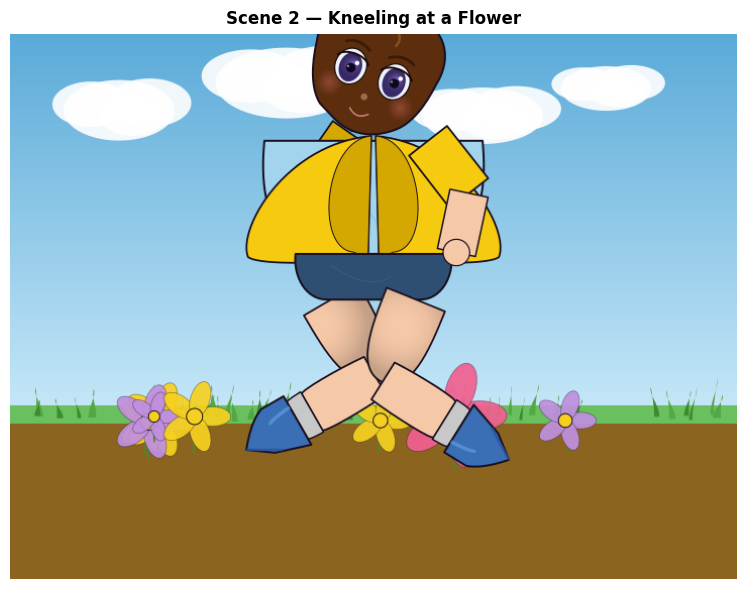

Scene 2 rendered


In [11]:
# Cell 9 — Scene 2: Kneeling to Examine a Flower

def scene2(ctx):
    rng = np.random.default_rng(11)
    for _ in range(7):
        fx = rng.uniform(60, W-60)
        fy = GROUND_Y + rng.integers(-5, 8)
        col = rng.choice([C['flower_pink'], C['flower_yel'], C['flower_lav']])
        draw_flower_cairo(ctx, fx, fy, size=rng.integers(12,22), color=col, rng=rng)

    # Prominent flower she's examining
    draw_flower_cairo(ctx, W//2 + 78, GROUND_Y - 2, size=30, color=C['flower_pink'])

    yuki.draw(ctx, ox=W//2, oy=GROUND_Y, scale=60,
              pose=dict(
                  facing     = 'front',
                  crouch     = 0.70,
                  head_tilt  = 20,
                  l_upper_leg=  30,  l_lower_leg= -90,
                  r_upper_leg= -22,  r_lower_leg=  80,
                  l_upper_arm=  55,  l_lower_arm= -65,
                  r_upper_arm=  38,  r_lower_arm= -50,
              ))

render_scene('Scene 2 — Kneeling at a Flower', scene2)
print('Scene 2 rendered')


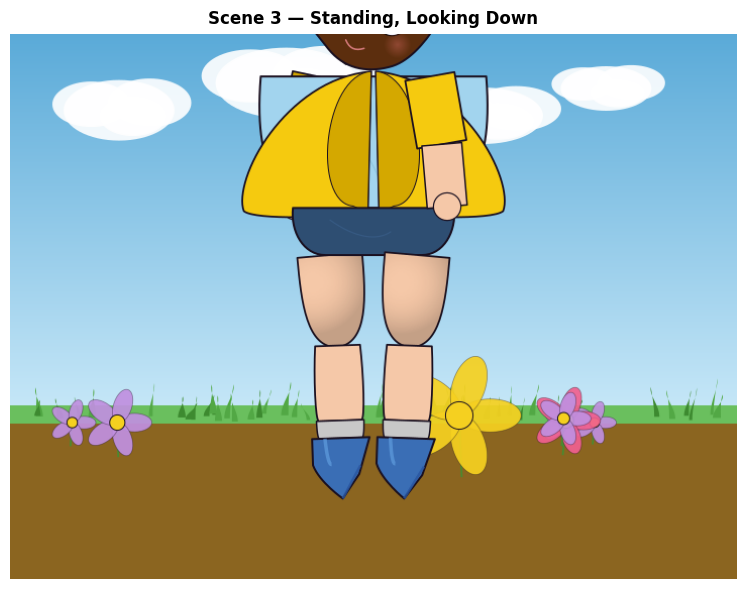

Scene 3 rendered


In [12]:
# Cell 10 — Scene 3: Standing, Looking Down at a Flower

def scene3(ctx):
    rng = np.random.default_rng(13)
    for _ in range(6):
        fx = rng.uniform(60, W-60)
        fy = GROUND_Y + rng.integers(-5, 8)
        col = rng.choice([C['flower_pink'], C['flower_lav']])
        draw_flower_cairo(ctx, fx, fy, size=rng.integers(12,20), color=col, rng=rng)

    # Large golden flower beside her
    draw_flower_cairo(ctx, W//2 + 85, GROUND_Y - 2, size=34, color=C['flower_yel'])

    yuki.draw(ctx, ox=W//2, oy=GROUND_Y, scale=62,
              pose=dict(
                  facing     = 'front',
                  head_tilt  = 25,          # tilted looking down
                  l_upper_arm= -12,
                  r_upper_arm=  10,
                  l_upper_leg=   5,
                  r_upper_leg=  -5,
              ))

render_scene('Scene 3 — Standing, Looking Down', scene3)
print('Scene 3 rendered')


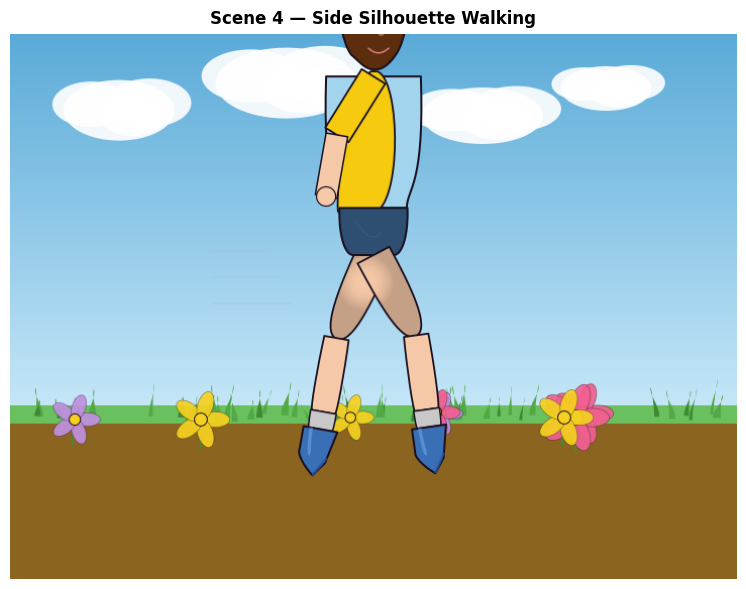

Scene 4 rendered


In [13]:
# Cell 11 — Scene 4: Side Silhouette Walking

def scene4(ctx):
    rng = np.random.default_rng(17)
    for _ in range(8):
        fx = rng.uniform(60, W-60)
        fy = GROUND_Y + rng.integers(-5, 8)
        col = rng.choice([C['flower_pink'], C['flower_yel'], C['flower_lav']])
        draw_flower_cairo(ctx, fx, fy, size=rng.integers(12,24), color=col, rng=rng)

    # Motion lines (speed streaks)
    for i, ly in enumerate(range(GROUND_Y-165, GROUND_Y-90, 26)):
        length = 55 + i * 12
        set_rgba(ctx, '#AABBDD', 0.35)
        ctx.move_to(W//2 - 160, ly)
        ctx.line_to(W//2 - 160 + length, ly)
        ctx.set_line_width(1.5)
        ctx.stroke()

    yuki.draw(ctx, ox=W//2, oy=GROUND_Y, scale=62,
              pose=dict(
                  facing     = 'side_r',
                  l_upper_leg=  28,  l_lower_leg= -20,
                  r_upper_leg= -24,  r_lower_leg=  14,
                  r_upper_arm= -32,  r_lower_arm=  22,
                  l_upper_arm=  20,  l_lower_arm= -12,
              ))

render_scene('Scene 4 — Side Silhouette Walking', scene4)
print('Scene 4 rendered')


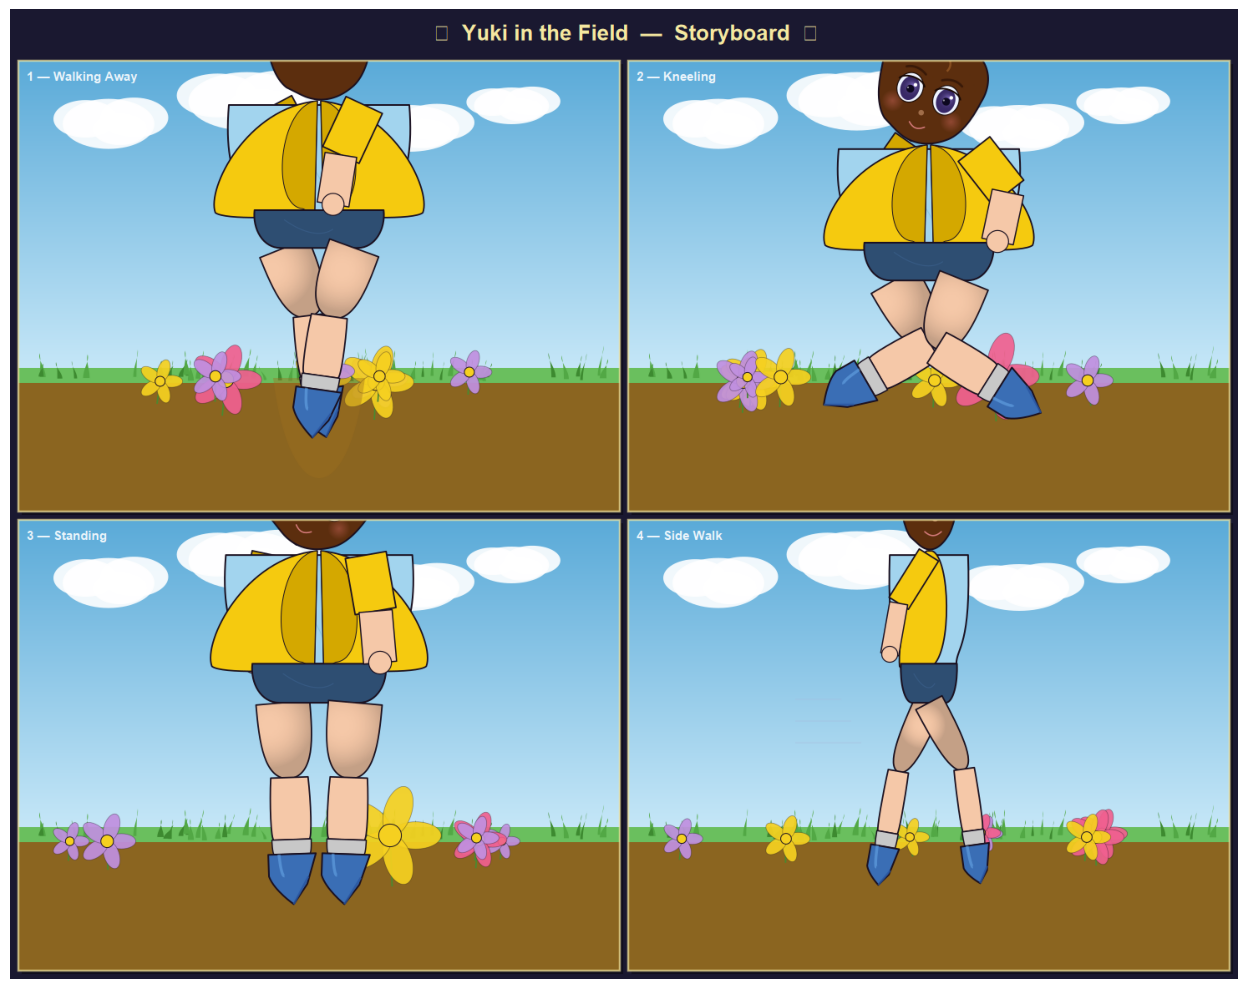

cairo.IOError: error while writing to output stream

In [14]:
# Cell 12 — Assemble 2×2 storyboard from the four stored surfaces

assert len(STORED_SURFACES) == 4, f'Expected 4 scenes, got {len(STORED_SURFACES)}'

BORDER  = 10
TITLE_H = 52
SW, SH  = W, H                        # each panel size
BW = SW*2 + BORDER*3                  # board width
BH = SH*2 + BORDER*3 + TITLE_H       # board height (+ title bar)

board_surf = cairo.ImageSurface(cairo.FORMAT_ARGB32, BW, BH)
bctx = cairo.Context(board_surf)

# Background
bctx.rectangle(0, 0, BW, BH)
set_rgba(bctx, '#1A1830')
bctx.fill()

# Title text
bctx.select_font_face('Sans', cairo.FONT_SLANT_NORMAL, cairo.FONT_WEIGHT_BOLD)
bctx.set_font_size(26)
title_str = '✦  Yuki in the Field  —  Storyboard  ✦'
te = bctx.text_extents(title_str)
bctx.move_to((BW - te.width) / 2, TITLE_H * 0.72)
set_rgba(bctx, '#F5E8A0')
bctx.show_text(title_str)

labels = ['1 — Walking Away', '2 — Kneeling', '3 — Standing', '4 — Side Walk']

for idx, (surf, lbl) in enumerate(zip(STORED_SURFACES, labels)):
    row, col = idx // 2, idx % 2
    px = BORDER + col * (SW + BORDER)
    py = TITLE_H + BORDER + row * (SH + BORDER)

    # Panel shadow
    bctx.rectangle(px+4, py+4, SW, SH)
    set_rgba(bctx, '#000000', 0.40)
    bctx.fill()

    # Paint panel
    bctx.set_source_surface(surf, px, py)
    bctx.rectangle(px, py, SW, SH)
    bctx.fill()

    # Panel border
    bctx.rectangle(px, py, SW, SH)
    bctx.set_line_width(2.5)
    set_rgba(bctx, '#F5E8A0', 0.70)
    bctx.stroke()

    # Panel label
    bctx.select_font_face('Sans', cairo.FONT_SLANT_NORMAL, cairo.FONT_WEIGHT_BOLD)
    bctx.set_font_size(15)
    bctx.move_to(px + 10, py + 24)
    set_rgba(bctx, '#FFFFFF', 0.88)
    bctx.show_text(lbl)

# Display the board
show_surface(board_surf, title='', figsize=(13, 10))

# Save PNG
board_surf.write_to_png('/tmp/storyboard_final.png')
print('Storyboard saved → /tmp/storyboard_final.png')
